In [8]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import scipy.io as sio

ROOT = Path("/projects/EEG-foundation-model/RECH202/speech_raw_datasets/kara_one/p/spoclab/users/szhao/EEG/data/MM05")
assert ROOT.exists(), ROOT
ROOT

PosixPath('/projects/EEG-foundation-model/RECH202/speech_raw_datasets/kara_one/p/spoclab/users/szhao/EEG/data/MM05')

In [9]:
def tree(path, max_depth=3):
    path = Path(path)
    rows = []
    for p in sorted(path.rglob("*")):
        depth = len(p.relative_to(path).parts)
        if depth <= max_depth:
            rows.append({
                "path": str(p.relative_to(path)),
                "type": "dir" if p.is_dir() else "file",
                "size_MB": None if p.is_dir() else p.stat().st_size / 1024**2,
                "suffix": p.suffix.lower()
            })
    return pd.DataFrame(rows)

df_tree = tree(ROOT, max_depth=3)
df_tree

,path,type,size_MB,suffix
0,.DS_Store,file,0.005863,
1,Acquisition 232 Data.cnt,file,652.428070,.cnt
2,Acquisition 232 Data.fdt,file,585.932922,.fdt
3,Acquisition 232 Data.set,file,0.048195,.set
4,all_features_ICA.mat,file,218.107757,.mat
...,...,...,...,...
510,set_files,dir,NaN,
511,set_files/Acquisition 232 Data.dap,file,0.004257,.dap
512,set_files/Acquisition 232 Data.fdt,file,585.932922,.fdt
513,set_files/Acquisition 232 Data.rs3,file,0.005441,.rs3


In [10]:
summary = (
    df_tree[df_tree["type"] == "file"]
    .groupby("suffix", dropna=False)
    .agg(
        n_files=("path", "count"),
        total_MB=("size_MB", "sum"),
        mean_MB=("size_MB", "mean"),
        max_MB=("size_MB", "max"),
    )
    .sort_values("total_MB", ascending=False)
)

summary

,n_files,total_MB,mean_MB,max_MB
suffix,,,,
.fdt,2,1171.865845,585.932922,585.932922
.cnt,1,652.428070,652.428070,652.428070
.mat,6,493.771488,82.295248,218.107757
.3d,165,30.353297,0.183959,0.257935
.wav,165,6.933020,0.042018,0.061567
.animu,165,0.581259,0.003523,0.004893
.set,2,0.096252,0.048126,0.048195
,1,0.005863,0.005863,0.005863
.rs3,1,0.005441,0.005441,0.005441


In [11]:
important_files = sorted([
    p for p in ROOT.rglob("*")
    if p.suffix.lower() in [".cnt", ".set", ".fdt", ".mat", ".wav", ".txt"]
])

pd.DataFrame({
    "file": [str(p.relative_to(ROOT)) for p in important_files],
    "suffix": [p.suffix.lower() for p in important_files],
    "size_MB": [p.stat().st_size / 1024**2 for p in important_files],
})

,file,suffix,size_MB
0,Acquisition 232 Data.cnt,.cnt,652.428070
1,Acquisition 232 Data.fdt,.fdt,585.932922
2,Acquisition 232 Data.set,.set,0.048195
3,all_features_ICA.mat,.mat,218.107757
4,all_features_noICA.mat,.mat,209.227819
...,...,...,...
175,kinect_data/labels.txt,.txt,0.000930
176,regression_features.mat,.mat,56.235082
177,regression_features_FFT.mat,.mat,2.411299
178,set_files/Acquisition 232 Data.fdt,.fdt,585.932922


In [12]:
mat_files = sorted(ROOT.glob("*.mat"))

for mat_path in mat_files:
    print("\n" + "=" * 80)
    print(mat_path.name)
    try:
        mat = sio.loadmat(mat_path, simplify_cells=True)
        keys = [k for k in mat.keys() if not k.startswith("__")]
        print("keys:", keys)

        for k in keys:
            v = mat[k]
            if hasattr(v, "shape"):
                print(f"  {k}: type={type(v).__name__}, shape={v.shape}, dtype={getattr(v, 'dtype', None)}")
            else:
                print(f"  {k}: type={type(v).__name__}")
    except NotImplementedError:
        print("Fichier probablement MATLAB v7.3/HDF5. Utiliser h5py.")


all_features_ICA.mat
keys: ['all_features']
  all_features: type=dict

all_features_noICA.mat
keys: ['all_features']
  all_features: type=dict

all_features_simple.mat
keys: ['all_features']
  all_features: type=dict

epoch_inds.mat
keys: ['clearing_inds', 'thinking_inds', 'speaking_inds']
  clearing_inds: type=ndarray, shape=(165,), dtype=object
  thinking_inds: type=ndarray, shape=(165,), dtype=object
  speaking_inds: type=ndarray, shape=(330,), dtype=object

regression_features.mat
keys: ['regression_features']
  regression_features: type=dict

regression_features_FFT.mat
keys: ['regression_features']
  regression_features: type=dict


In [13]:
epoch_path = ROOT / "epoch_inds.mat"
epoch = sio.loadmat(epoch_path, simplify_cells=True)

epoch.keys()

for k, v in epoch.items():
    if not k.startswith("__"):
        print(k, type(v), getattr(v, "shape", None))
        print(v if np.size(v) < 20 else "large array")

clearing_inds <class 'numpy.ndarray'> (165,)
large array
thinking_inds <class 'numpy.ndarray'> (165,)
large array
speaking_inds <class 'numpy.ndarray'> (330,)
large array


In [14]:
kinect_dir = ROOT / "kinect_data"

kinect_files = tree(kinect_dir, max_depth=2)
kinect_files

(
    kinect_files[kinect_files["type"] == "file"]
    .groupby("suffix")
    .agg(n_files=("path", "count"), total_MB=("size_MB", "sum"))
    .sort_values("n_files", ascending=False)
)

,n_files,total_MB
suffix,,
.3d,165,30.353297
.animu,165,0.581259
.wav,165,6.933020
.txt,4,0.003181


In [15]:
for name in ["ID.txt", "ID_p.txt", "labels.txt", "ID_ind.txt"]:
    path = kinect_dir / name
    print("\n" + "=" * 80)
    print(name)
    if path.exists():
        print(path.read_text(errors="replace")[:2000])
    else:
        print("absent")


ID.txt
absent

ID_p.txt
absent

labels.txt
/uw/
/tiy/
/tiy/
/uw/
/iy/
/m/
/n/
/iy/
/n/
/piy/
/uw/
/tiy/
/iy/
/diy/
/n/
/iy/
/tiy/
/piy/
/tiy/
/n/
/m/
/m/
/diy/
/uw/
/piy/
/tiy/
/m/
/n/
/tiy/
/n/
/piy/
/uw/
/uw/
/iy/
/m/
/tiy/
/tiy/
/n/
/diy/
/piy/
/iy/
/diy/
/uw/
/diy/
/m/
/uw/
/uw/
/piy/
/piy/
/piy/
/n/
/n/
/diy/
/piy/
/tiy/
/uw/
/tiy/
/diy/
/iy/
/n/
/m/
/diy/
/m/
/uw/
/m/
/piy/
/uw/
/piy/
/m/
/n/
/tiy/
/iy/
/uw/
/n/
/iy/
/uw/
/piy/
/tiy/
/n/
/m/
/diy/
/iy/
/diy/
/n/
/tiy/
/n/
/iy/
/iy/
/uw/
/diy/
/m/
/piy/
/iy/
/diy/
/diy/
/piy/
/m/
/tiy/
/iy/
/piy/
/iy/
/m/
/diy/
/diy/
/m/
gnaw
gnaw
gnaw
pat
knew
pat
pat
pot
pot
gnaw
knew
gnaw
pot
knew
pat
gnaw
pot
gnaw
knew
pat
knew
pat
gnaw
knew
pot
pot
knew
knew
gnaw
gnaw
pat
knew
gnaw
pat
pat
gnaw
pot
pat
knew
pot
knew
pat
pot
knew
knew
pot
pot
pat
pot
pot
gnaw
pot
pot
knew
gnaw
gnaw
pat
pat
pat
knew


ID_ind.txt
absent


In [16]:
# À installer si besoin :
# !pip install mne pymatreader

import mne

set_files = list(ROOT.glob("*.set"))
set_files

raw = mne.io.read_raw_eeglab(set_files[0], preload=False, verbose=True)

print(raw)
print("Sampling freq:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print(raw.ch_names)



Reading /projects/EEG-foundation-model/RECH202/speech_raw_datasets/kara_one/p/spoclab/users/szhao/EEG/data/MM05/Acquisition 232 Data.fdt


/tmp/ipykernel_27666/257167127.py:9: RuntimeWarning: Estimated head radius (12.5 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(set_files[0], preload=False, verbose=True)


<RawEEGLAB | Acquisition 232 Data.fdt, 62 x 2477400 (2477.4 s), ~74 KiB, data not loaded>
Sampling freq: 1000.0
Channels: 62
['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'OZ', 'O2', 'CB2', 'O1']


In [17]:
eeg_summary = {
    "n_channels": len(raw.ch_names),
    "sfreq": raw.info["sfreq"],
    "duration_sec": raw.n_times / raw.info["sfreq"],
    "duration_min": raw.n_times / raw.info["sfreq"] / 60,
    "channel_names": raw.ch_names,
}

eeg_summary

{'n_channels': 62,
 'sfreq': 1000.0,
 'duration_sec': np.float64(2477.4),
 'duration_min': np.float64(41.29),
 'channel_names': ['FP1',
  'FPZ',
  'FP2',
  'AF3',
  'AF4',
  'F7',
  'F5',
  'F3',
  'F1',
  'FZ',
  'F2',
  'F4',
  'F6',
  'F8',
  'FT7',
  'FC5',
  'FC3',
  'FC1',
  'FCZ',
  'FC2',
  'FC4',
  'FC6',
  'FT8',
  'T7',
  'C5',
  'C3',
  'C1',
  'CZ',
  'C2',
  'C4',
  'C6',
  'T8',
  'TP7',
  'CP5',
  'CP3',
  'CP1',
  'CPZ',
  'CP2',
  'CP4',
  'CP6',
  'TP8',
  'P7',
  'P5',
  'P3',
  'P1',
  'PZ',
  'P2',
  'P4',
  'P6',
  'P8',
  'PO7',
  'PO5',
  'PO3',
  'POZ',
  'PO4',
  'PO6',
  'PO8',
  'CB1',
  'OZ',
  'O2',
  'CB2',
  'O1']}

In [18]:
print(raw.annotations)

ann_df = pd.DataFrame({
    "onset": raw.annotations.onset,
    "duration": raw.annotations.duration,
    "description": raw.annotations.description,
})

ann_df.head(30)

ann_df["description"].value_counts()

<Annotations | 0 segments>


Series([], Name: count, dtype: int64)

Reading 0 ... 2477399  =      0.000 ...  2477.399 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using matplotlib as 2D backend.


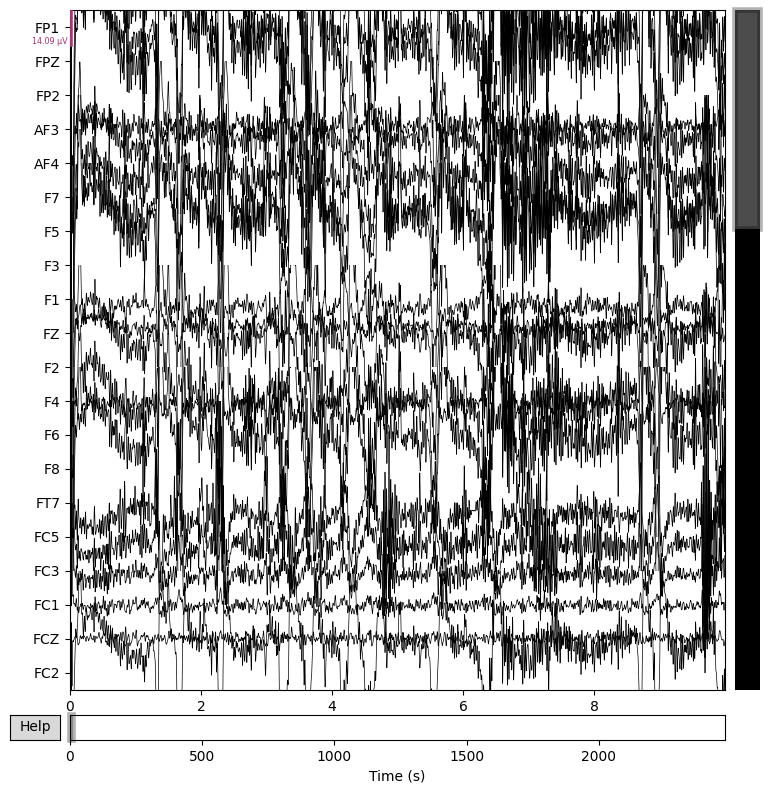

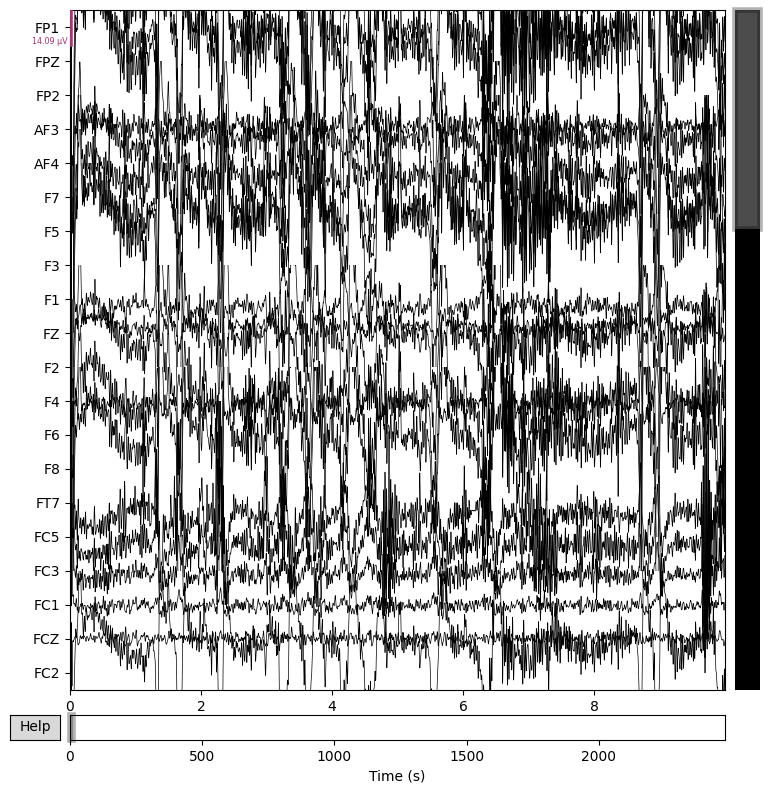

In [19]:
raw_preview = raw.copy().load_data()
raw_preview.pick_types(eeg=True)

raw_preview.plot(
    duration=10,
    n_channels=20,
    scalings="auto"
)

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


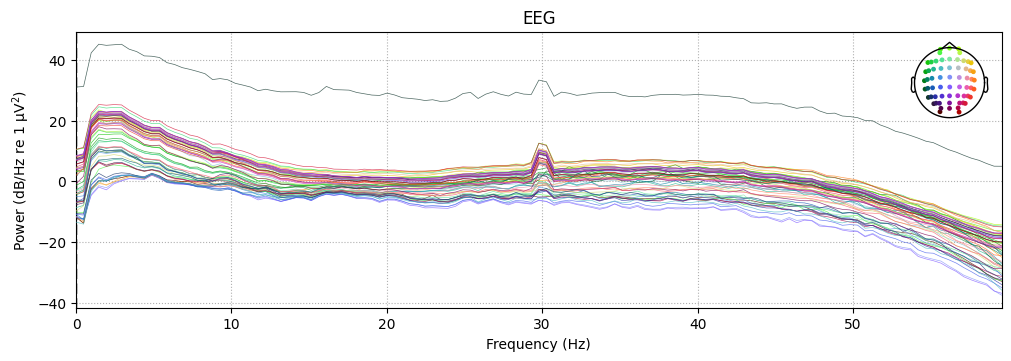

In [20]:
raw_preview.compute_psd(fmax=60).plot()

In [26]:
import numpy as np
import scipy.io as sio
import mne
from pathlib import Path

ROOT = Path(
    "/projects/EEG-foundation-model/RECH202/speech_raw_datasets/"
    "kara_one/p/spoclab/users/szhao/EEG/data/MM05"
)

EPOCH_TYPE = "thinking_inds"  # "thinking_inds", "speaking_inds", "clearing_inds"

raw = mne.io.read_raw_eeglab(
    ROOT / "Acquisition 232 Data.set",
    preload=True,
    verbose=False
)

eeg = raw.get_data()

epoch_mat = sio.loadmat(ROOT / "epoch_inds.mat", simplify_cells=True)

epoch_inds = np.asarray(epoch_mat[EPOCH_TYPE], dtype=object)

if epoch_inds.ndim == 1:
    epoch_inds = np.vstack(epoch_inds).astype(int)
elif epoch_inds.ndim == 2 and epoch_inds.shape[0] == 2 and epoch_inds.shape[1] != 2:
    epoch_inds = epoch_inds.T.astype(int)
else:
    epoch_inds = epoch_inds.astype(int)

labels_path = ROOT / "kinect_data" / "labels.txt"

labels = [
    line.strip()
    for line in labels_path.read_text(errors="replace").splitlines()
    if line.strip()
]

trials = []
trial_labels = []

n_trials = min(len(epoch_inds), len(labels))

for i in range(n_trials):
    start, end = epoch_inds[i]

    # Indices MATLAB probablement 1-based
    start = int(start) - 1
    end = int(end)

    trials.append(eeg[:, start:end])
    trial_labels.append(labels[i])

print("EEG continuous shape:", eeg.shape)
print("Epoch type:", EPOCH_TYPE)
print("Epoch indices shape:", epoch_inds.shape)
print("Number of labels:", len(labels))
print("Number of extracted trials:", len(trials))
print("First label:", trial_labels[0])
print("First trial shape:", trials[0].shape)

/tmp/ipykernel_27666/1571584024.py:13: RuntimeWarning: Estimated head radius (12.5 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(


EEG continuous shape: (62, 2477400)
Epoch type: thinking_inds
Epoch indices shape: (165, 2)
Number of labels: 165
Number of extracted trials: 165
First label: /uw/
First trial shape: (62, 4965)


In [27]:
import numpy as np
import scipy.io as sio
import mne
from pathlib import Path
from collections import Counter

ROOT = Path(
    "/projects/EEG-foundation-model/RECH202/speech_raw_datasets/"
    "kara_one/p/spoclab/users/szhao/EEG/data/MM05"
)

# ============================================================
# CONFIG ARTICLE
# ============================================================

N_PROMPTS = 11
N_REPETITIONS = 12
N_EXPECTED_TRIALS = N_PROMPTS * N_REPETITIONS  # 132

PROMPTS_EXPECTED = [
    "iy", "uw", "piy", "tiy", "diy", "m", "n",
    "pat", "pot", "knew", "gnaw"
]

# ============================================================
# LOAD EEG
# ============================================================

raw = mne.io.read_raw_eeglab(
    ROOT / "Acquisition 232 Data.set",
    preload=True,
    verbose=False
)

eeg = raw.get_data()
sfreq = raw.info["sfreq"]

print("EEG continuous shape:", eeg.shape)
print("Sampling frequency:", sfreq)
print("Duration min:", raw.n_times / sfreq / 60)

# ============================================================
# LOAD EPOCH INDICES
# ============================================================

epoch_mat = sio.loadmat(
    ROOT / "epoch_inds.mat",
    simplify_cells=True
)

def fix_epoch_inds(x):
    x = np.asarray(x, dtype=object)

    # Cas Kara One : shape (n_trials,), chaque élément = [start, end]
    if x.ndim == 1:
        x = np.vstack(x).astype(int)

    # Cas MATLAB : shape (2, n_trials)
    elif x.ndim == 2 and x.shape[0] == 2 and x.shape[1] != 2:
        x = x.T.astype(int)

    else:
        x = x.astype(int)

    if x.ndim != 2 or x.shape[1] != 2:
        raise ValueError(f"Invalid epoch shape: {x.shape}")

    return x

clearing_inds = fix_epoch_inds(epoch_mat["clearing_inds"])
thinking_inds = fix_epoch_inds(epoch_mat["thinking_inds"])
speaking_inds = fix_epoch_inds(epoch_mat["speaking_inds"])

print("\nOriginal number of epochs:")
print("clearing:", len(clearing_inds))
print("thinking:", len(thinking_inds))
print("speaking:", len(speaking_inds))

# ============================================================
# LOAD LABELS
# ============================================================

labels_path = ROOT / "kinect_data" / "labels.txt"

labels = [
    line.strip()
    for line in labels_path.read_text(errors="replace").splitlines()
    if line.strip()
]

print("\nOriginal number of labels:", len(labels))
print("Original label counts:")
print(Counter(labels))

# ============================================================
# KEEP ONLY ARTICLE-CONSISTENT 132 TRIALS
# ============================================================

n_available = min(
    len(labels),
    len(clearing_inds),
    len(thinking_inds),
    len(speaking_inds)
)

if n_available < N_EXPECTED_TRIALS:
    raise ValueError(
        f"Only {n_available} trials available, expected {N_EXPECTED_TRIALS}"
    )

labels_132 = labels[:N_EXPECTED_TRIALS]
clearing_inds_132 = clearing_inds[:N_EXPECTED_TRIALS]
thinking_inds_132 = thinking_inds[:N_EXPECTED_TRIALS]
speaking_inds_132 = speaking_inds[:N_EXPECTED_TRIALS]

print("\nKept trials:", len(labels_132))
print("Kept label counts:")
print(Counter(labels_132))

# ============================================================
# EXTRACT EEG TRIALS FOR EACH STATE
# ============================================================

def extract_trials(eeg, inds, matlab_1_based=True):
    trials = []

    for start, end in inds:
        if matlab_1_based:
            start = int(start) - 1
        else:
            start = int(start)

        end = int(end)

        trials.append(eeg[:, start:end])

    return trials

clearing_trials = extract_trials(eeg, clearing_inds_132)
thinking_trials = extract_trials(eeg, thinking_inds_132)
speaking_trials = extract_trials(eeg, speaking_inds_132)

# ============================================================
# MAIN OUTPUT FOR IMAGINED SPEECH
# ============================================================

trials = thinking_trials
trial_labels = labels_132

# ============================================================
# OPTIONAL: BUILD STRUCTURED DATASET
# ============================================================

dataset = []

for i in range(N_EXPECTED_TRIALS):
    dataset.append({
        "trial_id": i,
        "label": labels_132[i],
        "clearing_eeg": clearing_trials[i],
        "thinking_eeg": thinking_trials[i],
        "speaking_eeg": speaking_trials[i],
        "clearing_shape": clearing_trials[i].shape,
        "thinking_shape": thinking_trials[i].shape,
        "speaking_shape": speaking_trials[i].shape,
    })

# ============================================================
# CHECK DURATIONS
# ============================================================

def duration_stats(name, inds):
    durations = (inds[:, 1] - inds[:, 0]) / sfreq
    print(f"\n{name}")
    print("mean duration:", durations.mean())
    print("std duration:", durations.std())
    print("min duration:", durations.min())
    print("max duration:", durations.max())

duration_stats("clearing", clearing_inds_132)
duration_stats("thinking", thinking_inds_132)
duration_stats("speaking", speaking_inds_132)

# ============================================================
# SUMMARY
# ============================================================

print("\nFinal outputs:")
print("trials        -> imagined speech EEG, list of arrays")
print("trial_labels  -> labels associated with trials")
print("dataset       -> full structured dataset with 3 states")

print("\nExample:")
print("label:", trial_labels[0])
print("thinking trial shape:", trials[0].shape)
print("clearing trial shape:", dataset[0]["clearing_eeg"].shape)
print("speaking trial shape:", dataset[0]["speaking_eeg"].shape)

/tmp/ipykernel_27666/348612634.py:29: RuntimeWarning: Estimated head radius (12.5 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(


EEG continuous shape: (62, 2477400)
Sampling frequency: 1000.0
Duration min: 41.29

Original number of epochs:
clearing: 165
thinking: 165
speaking: 330

Original number of labels: 165
Original label counts:
Counter({'/uw/': 15, '/tiy/': 15, '/iy/': 15, '/m/': 15, '/n/': 15, '/piy/': 15, '/diy/': 15, 'gnaw': 15, 'pat': 15, 'knew': 15, 'pot': 15})

Kept trials: 132
Kept label counts:
Counter({'/uw/': 15, '/tiy/': 15, '/iy/': 15, '/m/': 15, '/n/': 15, '/piy/': 15, '/diy/': 15, 'gnaw': 8, 'knew': 7, 'pat': 6, 'pot': 6})

clearing
mean duration: 4.976757575757576
std duration: 0.010927530711756527
min duration: 4.947
max duration: 4.999

thinking
mean duration: 4.948969696969697
std duration: 0.014239796662841845
min duration: 4.911
max duration: 4.989

speaking
mean duration: 2.143113636363636
std duration: 0.2243075083426725
min duration: 1.87
max duration: 3.19

Final outputs:
trials        -> imagined speech EEG, list of arrays
trial_labels  -> labels associated with trials
dataset    